In [34]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [35]:
using Revise
includet("./base.jl")

In [36]:
using ColorSchemes
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Load

In [37]:
datadir = "data1_smallL"
figdir = "smallLfigures"

setup = load("systems1_smallL.jld2")
pde_df = setup["pde_df"]
smeta = setup["metadata"]

runs = collect_pde_runs(datadir)
runs.params = [pde_df.params[i] for i in runs.pde_df_row]
runs.hss = [pde_df.ode_hss[i] for i in runs.pde_df_row]  # reduced well-mixed steady state

xx = get_Ns.(runs.params)
runs.Ns = getindex.(xx, 1)
runs.Nr = getindex.(xx, 2)

pvals = sort(unique(runs.p))
sys_rows = sort(unique(runs.gdf_row))

@assert all(length.(runs.hss) .== runs.Ns .+ runs.Nr)

@show nrow(runs) nrow(pde_df) extrema(runs.Ns) extrema(runs.Nr) unique(runs.p) extrema(runs.L)
countmap(string.(runs.retcode))

nrow(runs) = 40
nrow(pde_df) = 40
extrema(runs.Ns) = (1, 7)
extrema(runs.Nr) = (5, 20)
unique(runs.p) = [1.0, 10.0]
extrema(runs.L) = (2.7644440895842433, 22.188626711044687)

Dict{String, Int64} with 2 entries:
  "Success" => 39
  "MaxTime" => 1

# Per-run metrics

Spatial *averages* rather than integrals: `L` differs between runs, so `mean` over `x` is the comparable quantity.

Peak region = the contiguous run of gridpoints above half max of the total strain biomass `B(x) = sum_i N_i(x)`, taken around the global max and wrapping over the periodic boundary.

In [38]:
"""
    fwhm_idxs(B)

Indices of the peak of the periodic profile `B`: the contiguous run of points
above half max, `(max + min) / 2`, containing the global maximum, wrapped over
the ends of the domain.
"""
function fwhm_idxs(B)
    n = length(B)
    half = (maximum(B) + minimum(B)) / 2
    imax = argmax(B)
    lo, hi = imax, imax
    while (hi - lo + 1) < n && B[mod1(lo - 1, n)] > half
        lo -= 1
    end
    while (hi - lo + 1) < n && B[mod1(hi + 1, n)] > half
        hi += 1
    end
    mod1.(lo:hi, n)
end

"""
    relamp(B)

Peak-to-trough amplitude of `B` relative to its mean; the flat/patterned test.
"""
relamp(B) = (maximum(B) - minimum(B)) / mean(B)

"""
    status_line(r)

How the run ended, for figure titles: the solver's return code, the time it
actually reached (`T` unless the `maxtime` timer cut it off) and the
steady-state residual there.
"""
status_line(r) = @sprintf("%s, final_T %.3g, maxresid %.1e", string(r.retcode), r.final_T, r.maxresid)

amp_thresh = 0.05    # below this a final state counts as unpatterned
alive_thresh = 1e-3  # total strain biomass below this fraction of the hss counts as collapsed

0.001

In [39]:
runs.Bx = [vec(sum(view(u, 1:ns, :); dims=1)) for (u, ns) in zip(runs.final_state, runs.Ns)]  # B(x), total strain biomass at each gridpoint
runs.relamp = relamp.(runs.Bx)              # (max - min) / mean of B(x), how strongly patterned the state is
runs.patterned = runs.relamp .> amp_thresh  # false when B(x) came out flat
runs.pk_idxs = fwhm_idxs.(runs.Bx)          # gridpoints inside the FWHM peak of B(x), wrapped over the boundary
runs.fwhm_frac = [length(is) / length(B) for (is, B) in zip(runs.pk_idxs, runs.Bx)]  # that peak's width as a fraction of L
runs.fwhm = runs.fwhm_frac .* runs.L        # that peak's width in units of x

runs.s_hss = [h[1:ns] for (h, ns) in zip(runs.hss, runs.Ns)]                                       # per strain, well-mixed steady state
runs.s_glob = [vec(mean(view(u, 1:ns, :); dims=2)) for (u, ns) in zip(runs.final_state, runs.Ns)]  # per strain, mean over the whole domain
runs.s_peak = [vec(mean(view(u, 1:ns, is); dims=2)) for (u, is, ns) in zip(runs.final_state, runs.pk_idxs, runs.Ns)]  # per strain, mean inside the peak

runs.B_hss = sum.(runs.s_hss)
runs.B_glob = sum.(runs.s_glob)
runs.B_peak = sum.(runs.s_peak)
runs.B_glob_rel = runs.B_glob ./ runs.B_hss
runs.B_peak_rel = runs.B_peak ./ runs.B_hss

# strains that died out entirely: relamp is meaningless there, it is noise over noise
runs.alive = runs.B_glob_rel .> alive_thresh

@show count(runs.alive) count(runs.patterned) count(runs.alive .& runs.patterned) nrow(runs);
combine(groupby(runs, :p),
    nrow => :n,
    :alive => count => :n_alive,
    :patterned => count => :n_patterned,
    :fwhm_frac => median => :fwhm_frac_med,
    :B_glob_rel => median => :B_glob_rel_med,
)

count(runs.alive) = 31
count(runs.patterned) = 34
count(runs.alive .& runs.patterned) = 25
nrow(runs) = 40

Row,p,n,n_alive,n_patterned,fwhm_frac_med,B_glob_rel_med
,Float64,Int64,Int64,Int64,Float64,Float64
1,1.0,20,20,20,0.1,0.575464
2,10.0,20,11,14,0.144,0.973882


# Spacetime diagrams

Colour is the local strain composition, lightness the total biomass normalised per timestep. One file per row in `smallLfigures/spacetime`.

In [40]:
"""
    spacetime_tmin(ts; tdecades=8, min_nt=6)

Where to start the log time axis. The solver's first steps are around `1e-16`,
so plotting every saved time spends most of the panel's height on a state that
has not moved yet. Cuts `tdecades` decades below the last saved time, but never
so high that fewer than `min_nt` states are left.
"""
function spacetime_tmin(ts; tdecades=8, min_nt=6)
    pos = sort(filter(>(0), ts))
    length(pos) <= min_nt && return nothing
    min(maximum(pos) * 10.0^(-tdecades), prevfloat(pos[end-min_nt+1]))
end

"""
    plot_run_spacetime!(where, r; kwargs...)

Space-time heatmap of one run's total strain biomass, on a log colour scale.
Pass `colorrange` to put every panel on the same scale.
"""
function plot_run_spacetime!(where, r; tmin=nothing, max_nt=1500, max_nx=1000, kwargs...)
    (; ts, us) = load_pde_states(datadir, r.pde_df_row)
    tmin = isnothing(tmin) ? spacetime_tmin(ts) : tmin
    data = spacetime_data(ts, us, r.Ns, r.L / r.sN; tmin, max_nt, max_nx, quiet=true)

    plot_spacetime_biomass!(where, data;
        colormap=:viridis, colorscale=log10,
        axis=(; titlesize=9,
            title=@sprintf("row %d, sys %d, p = %.3g\nL = %.3g, Ns = %d\n%s",
                r.pde_df_row, r.gdf_row, r.p, r.L, r.Ns, status_line(r))),
        kwargs...)
end

"""
    plot_system_spacetimes(rs; kwargs...)

One column per run in `rs` (a system's rows, ordered by `p`), sharing a single
colour scale and colourbar. Time is per panel - the runs do not end at the same
`final_T` and each one's own range is what is worth seeing.
"""
function plot_system_spacetimes(rs; width=330, height=400, kwargs...)
    fig = Figure(; size=(width * nrow(rs) + 90, height))
    hm = nothing
    for (j, r) in enumerate(eachrow(rs))
        hm = plot_run_spacetime!(fig[1, j], r; kwargs...).hm
    end
    Colorbar(fig[1, nrow(rs)+1], hm; label="total strain biomass")
    fig
end

plot_system_spacetimes

In [41]:
# One colour scale for every panel in every file, so a run whose biomass
# collapsed is a flat floor colour next to a live one instead of being restretched
# to look like a pattern. The floor is `colordecades` below the largest total
# biomass reached anywhere in the set; anything under it clamps.
colordecades = 6

B_max = Float64[]  # largest total strain biomass over the saved states, per run
@showprogress for r in eachrow(runs)
    (; ts, us) = load_pde_states(datadir, r.pde_df_row)
    push!(B_max, maximum(maximum(sum(view(u, 1:r.Ns, :); dims=1)) for u in us))
end
runs.B_max = B_max

st_colorrange = (maximum(runs.B_max) * 10.0^(-colordecades), maximum(runs.B_max))
@show st_colorrange extrema(runs.B_max) count(runs.B_max .< st_colorrange[1]);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04

st_colorrange = (2.1670736227508107e-5, 21.670736227508108)
extrema(runs.B_max) = (2.0869482577830607, 21.670736227508108)
count(runs.B_max .< st_colorrange[1]) = 0

In [42]:
stdir = joinpath(figdir, "spacetime")
mkpath(stdir)

@showprogress for i in sys_rows
    fig = plot_system_spacetimes(sort(runs[runs.gdf_row.==i, :], :p); colorrange=st_colorrange)
    Makie.save(joinpath(stdir, @sprintf("row%04d.pdf", i)), fig; backend=CairoMakie)
end
length(readdir(stdir))

Progress: 100%|█████████████████████████████████████████| Time: 0:00:04

21

# Final states

Each panel is circularly shifted so the biomass peak sits in the middle; the shaded band is the FWHM peak region, dashed lines the homogeneous steady state. One file per system in `figdir/fss`, a column per p.

In [43]:
"""
    plot_final_state!(where, r; title, hidex)

Strain and resource profiles of one run, shifted so the biomass peak is centred.
Thick black is the total strain biomass, dashed lines the homogeneous steady
state, the shaded band the FWHM peak region.
"""
function plot_final_state!(where, r; title="", hidex=false)
    ns, nr = r.Ns, r.Nr  # per system, after reduce_extinct
    scolors = Makie.resample_cmap(:viridis, max(ns, 2))
    rcolors = Makie.resample_cmap(:plasma, max(nr, 2))

    u, B = r.final_state, r.Bx
    n = size(u, 2)
    sh = div(n, 2) - argmax(B)
    uc, Bc = circshift(u, (0, sh)), circshift(B, sh)
    pk = sort(mod1.(r.pk_idxs .+ sh, n))
    xs = get_spatial_gridpoints_L(n, r.L)

    gl = GridLayout(where)
    axs = Axis(gl[1, 1]; ylabel="strains", title, titlesize=10)
    axr = Axis(gl[2, 1]; ylabel="resources", xlabel="x")
    linkxaxes!(axs, axr)
    hidexdecorations!(axs; grid=false)
    hidex && hidexdecorations!(axr; grid=false)
    rowgap!(gl, 4)

    for ax in (axs, axr)
        vspan!(ax, xs[first(pk)], xs[last(pk)]; color=(:grey, 0.2))
    end
    for i in 1:ns
        lines!(axs, xs, uc[i, :]; color=scolors[i], linewidth=0.7)
        hlines!(axs, r.hss[i]; color=scolors[i], linestyle=:dash, linewidth=0.4)
    end
    lines!(axs, xs, Bc; color=:black, linewidth=1.6)
    hlines!(axs, r.B_hss; color=:black, linestyle=:dash, linewidth=1.0)
    for a in 1:nr
        lines!(axr, xs, uc[ns+a, :]; color=rcolors[a], linewidth=0.7)
        hlines!(axr, r.hss[ns+a]; color=rcolors[a], linestyle=:dash, linewidth=0.4)
    end
    xlims!(axs, extrema(xs))

    axs, axr
end

"""
    plot_system_final_states(rs; kwargs...)

One column per run in `rs` (a system's rows, ordered by `p`).
"""
function plot_system_final_states(rs; width=250, height=170, kwargs...)
    fig = Figure(; size=(width * nrow(rs), 2 * height))
    for (j, r) in enumerate(eachrow(rs))
        plot_final_state!(fig[1, j], r;
            title=@sprintf("row %d, sys %d, p = %.3g\nrelamp %.2f, FWHM %.2f L\n%s",
                r.pde_df_row, r.gdf_row, r.p, r.relamp, r.fwhm_frac, status_line(r)),
            kwargs...)
    end
    fig
end

plot_system_final_states

In [44]:
fssdir = joinpath(figdir, "fss")
mkpath(fssdir)

@showprogress for i in sys_rows
    fig = plot_system_final_states(sort(runs[runs.gdf_row.==i, :], :p))
    Makie.save(joinpath(fssdir, @sprintf("row%04d.pdf", i)), fig; backend=CairoMakie)
end
length(readdir(fssdir))

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03

21

# Combined

Both of the above in one file per system: space-time diagrams along the top, the matching final states underneath, one column per p.

Columns are taken from `pde_df` rather than from `runs`, so a `(system, p)` whose row file is missing or unplottable still gets its column, blank and titled in red.

In [49]:
"""
    blank_panel!(where, title)

Placeholder for a `(system, p)` there is nothing to draw for: an empty axis with
a red title. Keeps the column in place so the same p is always in the same
position across files.
"""
function blank_panel!(where, title)
    ax = Axis(where; title, titlesize=9, titlecolor=:red)
    hidedecorations!(ax)
    hidespines!(ax)
    ax
end

"""
    plot_system_combined(i; kwargs...)

One system, one figure: space-time biomass along the top, the matching final
states underneath, a column per p, sharing the global `colorrange`.

The columns come from `pde_df`, not from `runs`, so a run that has no row file
yet - or whose states will not plot - is still given its column, blank and
titled in red, rather than dropping out and shifting everything along.
"""
function plot_system_combined(i;
    width=340, st_height=340, fs_height=170, colorrange=st_colorrange, kwargs...
)
    pis = sort(findall(==(i), pde_df.sys_i); by=k -> pde_df.p[k])  # this system's rows, by p

    fig = Figure(; size=(width * length(pis) + 90, st_height + 2 * fs_height))
    hm = nothing
    for (j, pi) in enumerate(pis)
        k = findfirst(==(pi), runs.pde_df_row)
        if isnothing(k)
            blank_panel!(fig[1, j], @sprintf("row %d, sys %d, p = %.3g\nno row file",
                pi, i, pde_df.p[pi]))
            blank_panel!(fig[2, j], "")
            continue
        end

        r = runs[k, :]
        try
            hm = plot_run_spacetime!(fig[1, j], r; colorrange, kwargs...).hm
        catch e
            blank_panel!(fig[1, j], @sprintf("row %d, sys %d, p = %.3g\n%s",
                pi, i, r.p, sprint(showerror, e)))
        end
        plot_final_state!(fig[2, j], r;
            title=@sprintf("relamp %.2f, FWHM %.2f L\n%s", r.relamp, r.fwhm_frac, status_line(r)))
    end

    isnothing(hm) || Colorbar(fig[1, length(pis)+1], hm; label="total strain biomass")
    rowsize!(fig.layout, 1, Relative(st_height / (st_height + 2 * fs_height)))

    fig
end

plot_system_combined

In [46]:
combdir = joinpath(figdir, "combined")
mkpath(combdir)

all_sys = sort(unique(pde_df.sys_i))  # every system in the setup, not just the ones with data

@showprogress for i in all_sys
    fig = plot_system_combined(i)
    Makie.save(joinpath(combdir, @sprintf("row%04d.pdf", i)), fig; backend=CairoMakie)
end
length(all_sys), length(sys_rows), length(readdir(combdir))

Progress: 100%|█████████████████████████████████████████| Time: 0:00:08

(20, 20, 20)

# Total biomass in time

One line per run, coloured by p. The quantity is the spatial *mean* of the total strain biomass, `mean_x sum_i N_i(x, t)`, since `L` differs between runs and the integral would just be `L` times it.

The series are computed once into `runs.bt` / `runs.bt_ts` so the normalisation can be flipped without re-reading the states.

In [51]:
bt_ts = Vector{Vector{Float64}}()  # saved times, per run
bt = Vector{Vector{Float64}}()     # mean over x of the total strain biomass at each of them

@showprogress for r in eachrow(runs)
    (; ts, us) = load_pde_states(datadir, r.pde_df_row)
    push!(bt_ts, ts)
    push!(bt, [mean(sum(view(u, 1:r.Ns, :); dims=1)) for u in us])
end
runs.bt_ts = bt_ts
runs.bt = bt

extrema(length.(runs.bt)), extrema(reduce(vcat, runs.bt))

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

((16, 8677), (0.0, 4.9591317960192045))

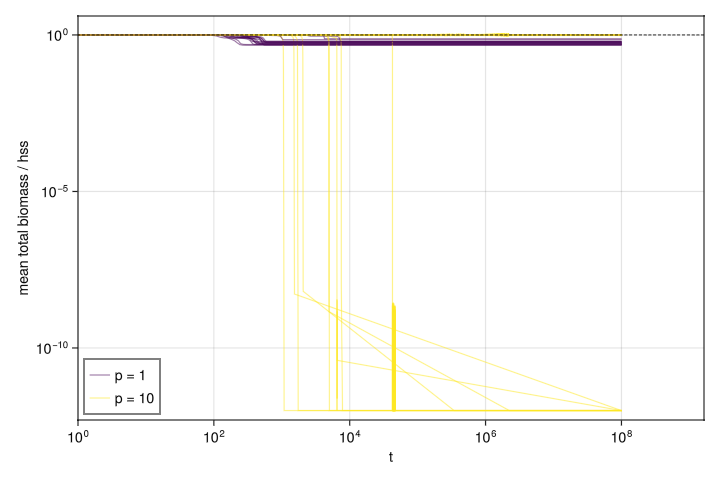

In [55]:
normalize_hss = true  # true divides each run by its own hss total, so 1 is the well-mixed level
bfloor = 1e-12        # below this a collapse is numerical noise; it just runs off the bottom
tdecades = 8          # decades of time to show, back from the last saved time

fig = Figure(; size=(720, 480))
ax = Axis(fig[1, 1]; xscale=log10, yscale=log10, xlabel="t",
    ylabel=normalize_hss ? "mean total biomass / hss" : "mean total biomass")

pcolors = Makie.resample_cmap(:viridis, max(length(pvals), 2))
for r in eachrow(runs)
    j = findfirst(==(r.p), pvals)
    ys = normalize_hss ? r.bt ./ r.B_hss : r.bt
    keep = r.bt_ts .> 0  # t = 0 cannot go on a log axis either
    lines!(ax, r.bt_ts[keep], clamp.(ys[keep], bfloor, Inf);
        color=(pcolors[j], 0.6), linewidth=1, label=@sprintf("p = %.3g", r.p))
end
normalize_hss && hlines!(ax, 1.0; color=:black, linestyle=:dash, linewidth=0.8)

# the solver's first steps are ~1e-16 and nothing moves there, same as the spacetime panels
xlims!(ax, maximum(maximum.(runs.bt_ts)) * 10.0^(-tdecades), nothing)
ylims!(ax, bfloor / 2, nothing)

axislegend(ax; position=:lb, merge=true, unique=true)
# backend=CairoMakie explicitly: the Interactive view cell leaves GLMakie active,
# and GLMakie cannot write a PDF. Saying it here beats switching the global backend
Makie.save(joinpath(figdir, normalize_hss ? "biomass_in_time_rel.pdf" : "biomass_in_time.pdf"), fig;
    backend=CairoMakie)
fig

# hss vs spatially structured mean abundances

One point per strain per run: its well-mixed steady state abundance against its mean over the domain in the PDE final state.

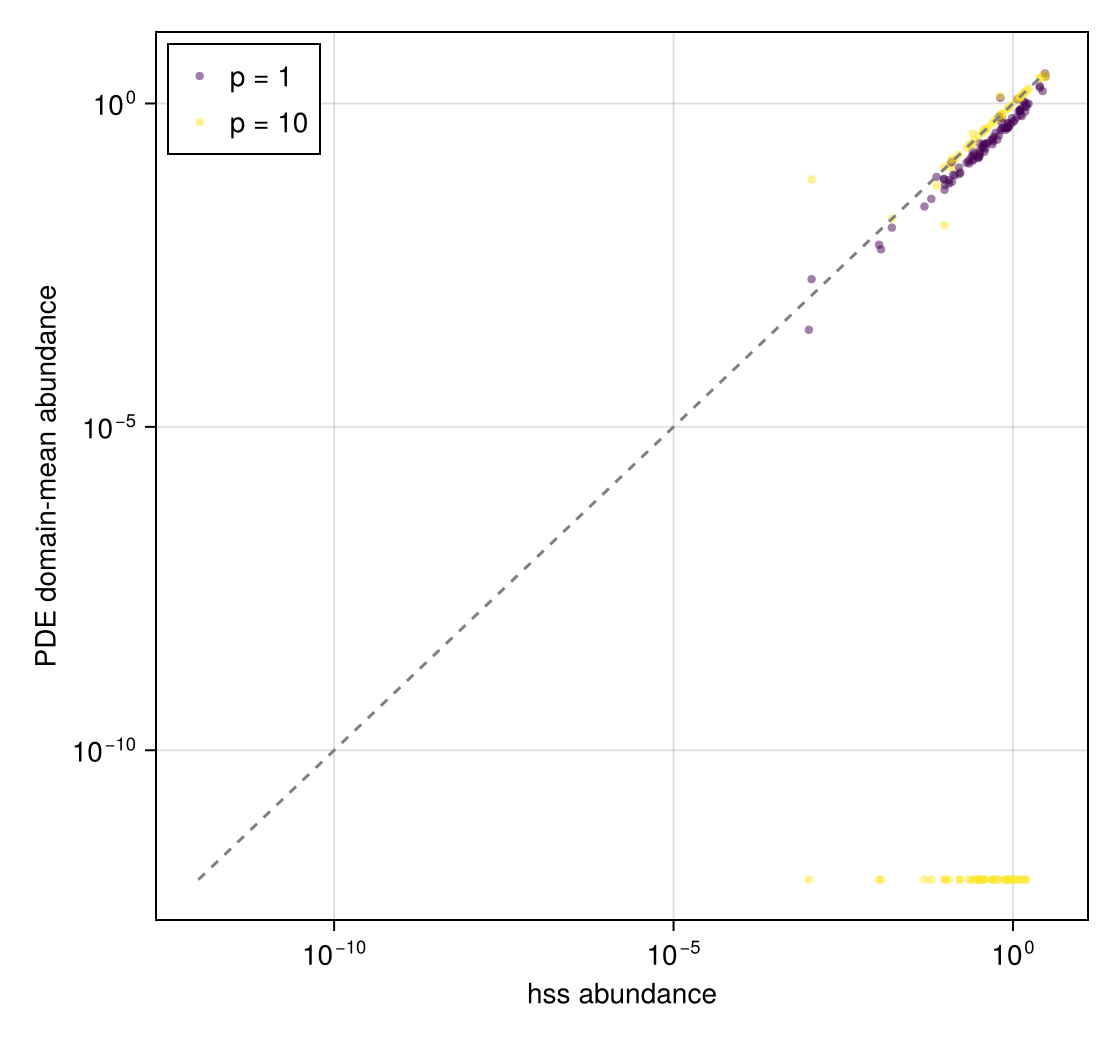

In [47]:
clip = 1e-12  # zeros cannot go on a log axis

fig = Figure(; size=(560, 520))
ax = Axis(fig[1, 1]; xscale=log10, yscale=log10,
    xlabel="hss abundance", ylabel="PDE domain-mean abundance")

pcolors = Makie.resample_cmap(:viridis, max(length(pvals), 2))
for r in eachrow(runs)
    j = findfirst(==(r.p), pvals)
    scatter!(ax, clamp.(r.s_hss, clip, Inf), clamp.(r.s_glob, clip, Inf);
        markersize=6, color=(pcolors[j], 0.5), label=@sprintf("p = %.3g", r.p))
end

allv = clamp.(reduce(vcat, vcat(runs.s_hss, runs.s_glob)), clip, Inf)
lo, hi = extrema(allv)
lines!(ax, [lo, hi], [lo, hi]; color=:grey, linestyle=:dash)  # y = x

axislegend(ax; position=:lt, merge=true, unique=true)
Makie.save(joinpath(figdir, "hss_vs_mean_scatter.pdf"), fig; backend=CairoMakie)
fig

# Interactive view

The spatial state at a chosen save, same as main4_totbiom's Row28. GLMakie, opens in its own window.

`SYS` and `P` pick the run and are plain variables rather than sliders: changing either loads a different row off disk and changes `Ns`, `Nr`, `L` and the number of saves, so the figure has to be rebuilt rather than updated. Rerun the cell after changing them. The save index *is* a slider.

In [56]:
SYS = 12                 # system to look at, ie gdf_row / pde_df.sys_i
P = 10.                 # which p of that system
share_threshold = 0.01  # only strains/resources holding this share of the total get a legend entry

GLMakie.activate!()

ri = findfirst((runs.gdf_row .== SYS) .& isapprox.(runs.p, P))
isnothing(ri) && error(@sprintf("no run for sys %d at p = %g - systems are %s, ps are %s",
    SYS, P, string(sys_rows), string(pvals)))
r = runs[ri, :]
ns, nr = r.Ns, r.Nr

(; ts, us) = load_pde_states(datadir, r.pde_df_row)
xs = get_spatial_gridpoints_L(r.sN, r.L)

ymaxN = maximum(maximum(sum(view(u, 1:ns, :); dims=1)) for u in us)  # the total, which is above every single strain
ymaxR = maximum(maximum(view(u, (ns+1):(ns+nr), :)) for u in us)

# every strain and resource is drawn. Only the ones carrying a share of the total
# get a legend entry - 20 a panel is unreadable - and the shares are summed over
# the whole series, so a colour and a label mean the same at every slider position.
tot_s = [sum(sum(view(u, s, :)) for u in us) for s in 1:ns]
tot_r = [sum(sum(view(u, ns + a, :)) for u in us) for a in 1:nr]
share_s = tot_s ./ sum(tot_s)
share_r = tot_r ./ sum(tot_r)
bigN = findall(>=(share_threshold), share_s)
bigR = findall(>=(share_threshold), share_r)

ncols = Makie.resample_cmap(ColorSchemes.tab20, max(ns, 2))
rcols = Makie.resample_cmap(ColorSchemes.tab20b, max(nr, 2))

fig = Figure(; size=(1000, 700))
sl = Slider(fig[3, 1], range=eachindex(ts), startvalue=length(ts))
u_at = lift(i -> us[i], sl.value)

axN = Axis(fig[1, 1]; ylabel="N",
    title=lift(i -> @sprintf("row %d, sys %d, p = %.3g, L = %.3g - save %d of %d, t = %.6g\n%s",
        r.pde_df_row, SYS, r.p, r.L, i, length(ts), ts[i], status_line(r)), sl.value))
pN = [lines!(axN, xs, lift(u -> u[s, :], u_at); color=ncols[s], linewidth=1) for s in 1:ns]
ptot = lines!(axN, xs, lift(u -> vec(sum(view(u, 1:ns, :), dims=1)), u_at);
    color=:black, linestyle=:dash, linewidth=1)
hlines!(axN, r.B_hss; color=:black, linewidth=0.6)  # the well-mixed total, for scale
ylims!(axN, -0.02ymaxN, 1.05ymaxN)
axislegend(axN, vcat(pN[bigN], [ptot]),
    vcat([@sprintf("N%d (%.1f%%)", s, 100share_s[s]) for s in bigN], ["total"]);
    position=:rt, nbanks=2, framevisible=true)

axR = Axis(fig[2, 1]; xlabel="x", ylabel="R")
pR = [lines!(axR, xs, lift(u -> u[ns+a, :], u_at); color=rcols[a], linewidth=1) for a in 1:nr]
ylims!(axR, -0.02ymaxR, 1.05ymaxR)
axislegend(axR, pR[bigR], [@sprintf("R%d (%.1f%%)", a, 100share_r[a]) for a in bigR];
    position=:rt, nbanks=2, framevisible=true)

# left/right arrows step one save; hold to repeat. Needs the GLMakie window focused.
on(events(fig).keyboardbutton) do e
    if e.action in (Keyboard.press, Keyboard.repeat)
        i, rr = sl.value[], sl.range[]
        e.key == Keyboard.left && set_close_to!(sl, max(first(rr), i - 1))
        e.key == Keyboard.right && set_close_to!(sl, min(last(rr), i + 1))
    end
    Consume(false)
end

linkxaxes!(axN, axR)
hidexdecorations!(axN; grid=false)
Label(fig[4, 1], "drag the slider or use left/right arrows; ylims are fixed to the whole series so frames are comparable";
    color=:grey50, tellwidth=false)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)